# Chronic mortality housing queue

This notebook sets up the baseline housing-allocation simulation for the next three figures. Time is measured in **years**, while the observed arrival and housing rates are entered per month and converted below.

The system has two true groups:

- **Chronic homelessness:** people remain in the queue unless housed or they die. In this model, chronic abandonment is interpreted as mortality before housing.
- **Non-chronic homelessness:** people may leave the queue by finding another housing arrangement; their patience is therefore shorter.

Housing is consumable: a monthly placement uses one unit permanently during the simulation horizon.

In [125]:
from dataclasses import dataclass
from functools import cached_property
from math import erf, exp, log, pi, sqrt
from pathlib import Path
import sys

from joblib import Parallel, delayed

# Find the repository's src directory regardless of where Jupyter starts.
for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    src_dir = candidate / "src"
    if (src_dir / "gi_gi_n_gi_multiclass").is_dir():
        PROJECT_ROOT = candidate
        sys.path.insert(0, str(src_dir))
        break
else:
    raise ImportError("Could not find src/gi_gi_n_gi_multiclass from this notebook location.")

import numpy as np
import pandas as pd
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from gi_gi_n_gi_multiclass.core.engine_multi import run_sim_multi
from gi_gi_n_gi_multiclass.core.types_multi import CustomerClass, MultiSimConfig
from gi_gi_n_gi_multiclass.dists.common import Deterministic, Exponential, LogNormal
from gi_gi_n_gi_multiclass.labelling import ConfusionMatrixClassifier
from gi_gi_n_gi_multiclass.outputs.schemas import customers_to_dataframe
from gi_gi_n_gi_multiclass.policies.priority_fcfs import PriorityFCFS

## Population, arrivals and housing

There are 750 new applicants per month, of whom 38% are truly chronic. The system starts with 8,000 people already waiting, allocated in the same proportions.

There are 250 new housing placements each month. No housing is available at time zero. Every person, including the initial queue, must wait at least six months before being eligible for an offer.

The policy gives people classified as chronic priority and uses FCFS within each assigned group. Classifier accuracy therefore determines how well scarce housing is directed to true chronic people.

In [106]:
MONTHS_PER_YEAR = 12

ARRIVALS_PER_MONTH = 750
CHRONIC_SHARE = 0.38
CHRONIC_ARRIVAL_RATE = ARRIVALS_PER_MONTH * CHRONIC_SHARE * MONTHS_PER_YEAR
NONCHRONIC_ARRIVAL_RATE = ARRIVALS_PER_MONTH * (1.0 - CHRONIC_SHARE) * MONTHS_PER_YEAR

INITIAL_QUEUE_SIZE = 8_000
INITIAL_CHRONIC = int(INITIAL_QUEUE_SIZE * CHRONIC_SHARE)
INITIAL_NONCHRONIC = INITIAL_QUEUE_SIZE - INITIAL_CHRONIC
INITIAL_QUEUE_COUNTS = [INITIAL_CHRONIC, INITIAL_NONCHRONIC]

HOUSING_PER_MONTH = 250
HOUSING_RELEASE_INTERVAL = 1.0 / MONTHS_PER_YEAR
FIRST_HOUSING_RELEASE = HOUSING_RELEASE_INTERVAL
INITIAL_HOUSING_STOCK = 0
ELIGIBILITY_DELAY = 6.0 / MONTHS_PER_YEAR

SIMULATION_YEARS = 10.0
SEED = 2026

assert INITIAL_CHRONIC + INITIAL_NONCHRONIC == INITIAL_QUEUE_SIZE
assert HOUSING_PER_MONTH < ARRIVALS_PER_MONTH

## Chronic mortality as abandonment

For chronic people, abandonment means death before housing. The calibration sets the probability of death by 30 months to 4%. The conditional timing of death follows a Gamma distribution with shape $$1.5$$ and scale $$7.3/2.5=2.92$$ years.

The Gamma curve is scaled so that

$$P(\text{death by }2.5\text{ years})=0.04.$$

Thus most chronic people have infinite patience in the simulation: they remain until housed or the horizon ends. The non-chronic lognormal patience distribution is retained as the current working assumption from the parameter sheet and can be replaced when exit data are available.

In [107]:
@dataclass(frozen=True)
class ScaledGammaMortality:
    """Defective Gamma patience: finite times represent chronic mortality."""

    shape: float = 1.5
    scale_years: float = 7.3 / 2.5
    calibration_window_years: float = 30.0 / 12.0
    mortality_by_window: float = 0.04

    def _gamma_cdf(self, time_years: float) -> float:
        """Gamma CDF for the specified shape 3/2."""
        if time_years <= 0.0:
            return 0.0
        x = time_years / self.scale_years
        return erf(sqrt(x)) - (2.0 / sqrt(pi)) * sqrt(x) * exp(-x)

    @cached_property
    def eventual_mortality_probability(self) -> float:
        return self.mortality_by_window / self._gamma_cdf(self.calibration_window_years)

    def sample(self, rng: np.random.Generator) -> float:
        if not 0.0 <= self.eventual_mortality_probability <= 1.0:
            raise ValueError("Mortality calibration implies an invalid probability.")
        if rng.random() >= self.eventual_mortality_probability:
            return float("inf")
        return float(rng.gamma(shape=self.shape, scale=self.scale_years))


chronic_mortality = ScaledGammaMortality()
# Working assumption: a substantial non-chronic share exits before the
# six-month eligibility point. Replace this with observed exit data.
NONCHRONIC_PATIENCE = LogNormal(meanlog=-1.0, sdlog=1.0)
nonchronic_exit_by_six_months = 0.5 * (
    1.0 + erf((log(0.5) - NONCHRONIC_PATIENCE.meanlog) / (NONCHRONIC_PATIENCE.sdlog * sqrt(2.0)))
)

mortality_check = chronic_mortality.eventual_mortality_probability * chronic_mortality._gamma_cdf(
    chronic_mortality.calibration_window_years
)
assert np.isclose(mortality_check, 0.04)
print(f"Calibrated chronic mortality by 30 months: {mortality_check:.1%}")
print(f"Non-chronic exit probability by six months: {nonchronic_exit_by_six_months:.1%}")

Calibrated chronic mortality by 30 months: 4.0%
Non-chronic exit probability by six months: 62.1%


## Simulation configuration

New applicants arrive through ordinary renewal processes, here Poisson arrivals implemented through exponential interarrival times. Housing releases remain discrete and monthly.

The initial 8,000 people are treated as entering the observed queue at time zero, so their six-month eligibility clock begins at time zero. This is a starting-backlog approximation; it can later be refined if queue-age data are available.

The figure simulations use the same asymmetric classifier path as the earlier studies: for balanced accuracy $$a$$, sensitivity is $$a+0.05$$ and specificity is $$a-0.05$$.

In [108]:
chronic = CustomerClass(
    name="chronic",
    interarrival=Exponential(rate=CHRONIC_ARRIVAL_RATE),
    service=Deterministic(0.0),
    patience=chronic_mortality,
)

nonchronic = CustomerClass(
    name="nonchronic",
    interarrival=Exponential(rate=NONCHRONIC_ARRIVAL_RATE),
    service=Deterministic(0.0),
    patience=NONCHRONIC_PATIENCE,
)

classes = [chronic, nonchronic]
baseline_policy = PriorityFCFS(priority_order=[0, 1])

def classifier_from_accuracy(accuracy: float) -> ConfusionMatrixClassifier:
    sensitivity = accuracy + 0.05
    specificity = accuracy - 0.05
    if not (0.0 <= sensitivity <= 1.0 and 0.0 <= specificity <= 1.0):
        raise ValueError("Accuracy must keep sensitivity and specificity in [0, 1].")
    return ConfusionMatrixClassifier(
        np.array([
            [sensitivity, 1.0 - sensitivity],
            [1.0 - specificity, specificity],
        ])
    )

def make_baseline_config(
    seed: int = SEED,
    run_years: float = SIMULATION_YEARS,
    classifier_accuracy: float = 0.8,
    housing_per_month: int = HOUSING_PER_MONTH,
    mandatory_wait_months: int = 6,
) -> MultiSimConfig:
    return MultiSimConfig(
        n_servers=int(housing_per_month),
        classes=classes,
        policy=baseline_policy,
        classifier=classifier_from_accuracy(classifier_accuracy),
        seed=seed,
        warmup_time=0.0,
        run_time=run_years,
        housing_mode=True,
        housing_arrival_mode="renewal",
        last_arrival_time=run_years,
        initial_queue_counts=INITIAL_QUEUE_COUNTS,
        housing_release_interval=HOUSING_RELEASE_INTERVAL,
        first_housing_release=FIRST_HOUSING_RELEASE,
        initial_housing_stock=INITIAL_HOUSING_STOCK,
        eligibility_delay=mandatory_wait_months / MONTHS_PER_YEAR,
        collect_event_log=False,
    )


def run_baseline(
    seed: int = SEED,
    run_years: float = SIMULATION_YEARS,
    classifier_accuracy: float = 0.8,
    housing_per_month: int = HOUSING_PER_MONTH,
    mandatory_wait_months: int = 6,
):
    result = run_sim_multi(
        make_baseline_config(
            seed=seed,
            run_years=run_years,
            classifier_accuracy=classifier_accuracy,
            housing_per_month=housing_per_month,
            mandatory_wait_months=mandatory_wait_months,
        )
    )
    customers = customers_to_dataframe(result)
    customers["is_initial_queue"] = customers["customer_id"] < INITIAL_QUEUE_SIZE
    return result, customers

## Baseline parameters

This table is a compact check on the quantities that will remain fixed across the three forthcoming figures.

In [109]:
pd.DataFrame(
    [
        ("New applicants", ARRIVALS_PER_MONTH, "per month"),
        ("True chronic share", CHRONIC_SHARE, "proportion"),
        ("Initial queue", INITIAL_QUEUE_SIZE, "people"),
        ("Initial chronic queue", INITIAL_CHRONIC, "people"),
        ("Housing released", HOUSING_PER_MONTH, "placements per month"),
        ("Minimum eligibility wait", ELIGIBILITY_DELAY * MONTHS_PER_YEAR, "months"),
        ("Chronic mortality by 30 months", mortality_check, "proportion"),
        ("Non-chronic exit by six months", nonchronic_exit_by_six_months, "proportion"),
    ],
    columns=["Parameter", "Value", "Unit"],
)

,Parameter,Value,Unit
0,New applicants,750.000000,per month
1,True chronic share,0.380000,proportion
2,Initial queue,8000.000000,people
3,Initial chronic queue,3040.000000,people
4,Housing released,250.000000,placements per month
5,Minimum eligibility wait,6.000000,months
6,Chronic mortality by 30 months,0.040000,proportion
7,Non-chronic exit by six months,0.620522,proportion


## Figure simulations

All four figures use the chronic mortality outcome $$P(\text{death before housing} \mid \text{true chronic})$$. Queue length is the unresolved on-street population at the end of a five-year horizon, split by true class.

The final contour uses 1 to 12 months.

In [143]:
FIGURE_HORIZON_YEARS = 5.0
# Average every plotted scenario over independent replications.
FIGURE_SEEDS = list(range(1, 21))
# More processes than physical CPU cores slows the simulation through contention.
# Set to 1 for serial debugging.
N_WORKERS = 16

WAIT_MONTH_GRID = np.arange(1, 13)
PLOT_ACCURACIES = [0.55, 0.70, 0.85]
CONTOUR_ACCURACIES = np.arange(0.5, 0.91, 0.1)
# The wait-time figures need both the plotted and contour accuracy values.
WAIT_GRID_ACCURACIES = np.array(sorted(set(PLOT_ACCURACIES).union(CONTOUR_ACCURACIES)))
HOUSING_SUPPLY_GRID = np.arange(100, 501, 50)

# Shared figure geometry and typography. Every saved figure uses this
# same canvas, so font sizes remain visually comparable across figures.
FIGURE_WIDTH = 7.0
FIGURE_HEIGHT = 5.0
FIGURE_SIZE = (FIGURE_WIDTH, FIGURE_HEIGHT)
# Separate geometry for the optional three-panel version of Figure 2.
FIGURE_2_COMBINED_WIDTH = 11.0
FIGURE_2_COMBINED_HEIGHT = 4.0
FIGURE_DPI = 200
FONT_SIZE = 13
TITLE_FONT_SIZE = FONT_SIZE * 1.2

matplotlib.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": TITLE_FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "figure.titlesize": TITLE_FONT_SIZE,
})

def save_figure(fig, filename, rect=None):
    fig.tight_layout(pad=0.8, rect=rect)
    fig.savefig(FIGURE_DIR / filename, dpi=FIGURE_DPI)

FIGURE_DIR = PROJECT_ROOT / "04_homeless_studies" / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

def summarise_scenario(classifier_accuracy, housing_per_month, mandatory_wait_months, seed):
    # Figure grids only need aggregate outcomes. Avoid constructing a large
    # pandas table for every scenario.
    result = run_sim_multi(
        make_baseline_config(
            seed=seed,
            run_years=FIGURE_HORIZON_YEARS,
            classifier_accuracy=classifier_accuracy,
            housing_per_month=housing_per_month,
            mandatory_wait_months=mandatory_wait_months,
        )
    )
    chronic_total = 0
    chronic_deaths = 0
    end_queue_chronic = 0
    end_queue_nonchronic = 0
    for customer in result.customers:
        if customer.true_class_id == 0:
            chronic_total += 1
            chronic_deaths += customer.outcome == "ABANDONED"
        if customer.outcome == "IN_SYSTEM_END":
            if customer.true_class_id == 0:
                end_queue_chronic += 1
            else:
                end_queue_nonchronic += 1
    return {
        "classifier_accuracy": classifier_accuracy,
        "housing_per_month": housing_per_month,
        "mandatory_wait_months": mandatory_wait_months,
        "seed": seed,
        "chronic_mortality_probability": chronic_deaths / chronic_total,
        "end_queue_chronic": end_queue_chronic,
        "end_queue_nonchronic": end_queue_nonchronic,
    }

def run_grid(accuracies, housing_values, wait_months):
    scenarios = [
        (float(accuracy), int(housing_per_month), int(mandatory_wait_months), int(seed))
        for accuracy in accuracies
        for housing_per_month in housing_values
        for mandatory_wait_months in wait_months
        for seed in FIGURE_SEEDS
    ]
    rows = Parallel(n_jobs=N_WORKERS, prefer="processes")(
        delayed(summarise_scenario)(*scenario) for scenario in scenarios
    )
    return pd.DataFrame(rows)

def mean_outcomes(raw):
    return raw.groupby(
        ["classifier_accuracy", "housing_per_month", "mandatory_wait_months"],
        as_index=False,
    ).mean(numeric_only=True)

## Figure 1: chronic mortality versus mandatory wait

A short enforced wait makes false-positive non-chronic people eligible quickly. A longer wait lets some leave before taking housing capacity, but an overly long wait exposes true chronic people to mortality.

In [ ]:
wait_raw = run_grid(WAIT_GRID_ACCURACIES, [HOUSING_PER_MONTH], WAIT_MONTH_GRID)
wait_summary = mean_outcomes(wait_raw)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
line_colours = {0.55: "#007C91", 0.70: "#D17800", 0.85: "#A23E66"}
for accuracy in PLOT_ACCURACIES:
    data = wait_summary[wait_summary["classifier_accuracy"] == accuracy]
    ax.plot(data["mandatory_wait_months"], data["chronic_mortality_probability"], color=line_colours[accuracy], marker="o", markersize=5, linewidth=2.4, label=f"Classifier accuracy {accuracy:.2f}")
ax.axvline(6, color="#303030", linestyle="--", linewidth=1.2, label="Current 6-month wait")
ax.set(xlabel="Mandatory wait before housing offer (months)", ylabel="P(death before housing | true chronic)", title="Chronic mortality versus mandatory wait")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7)
ax.set_ylim(0.0151, 0.0225)
legend = ax.legend(frameon=True, fancybox=False, framealpha=1.0, edgecolor="#303030")
legend.get_frame().set_facecolor("white")
legend.get_frame().set_linewidth(1.0)

save_figure(fig, "figure_1_mortality_vs_wait.png")
plt.show()

## Figure 2: end-of-horizon queue composition

The stacked bars show the unresolved population after five years. Accuracy should mostly change who receives housing and therefore mortality, rather than create housing or mechanically reduce the total on-street population.

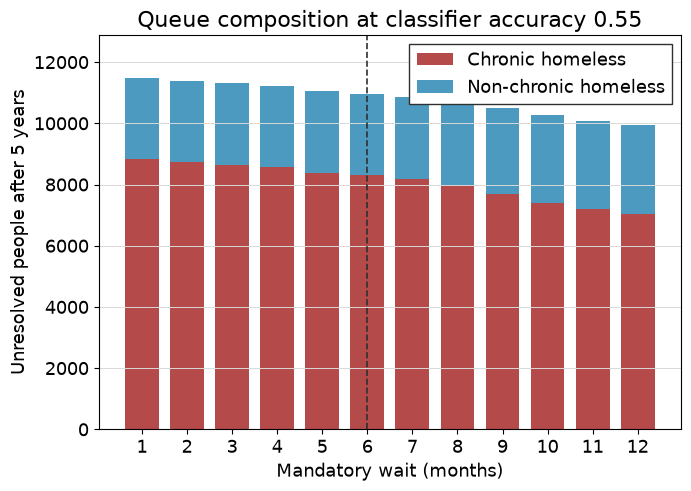

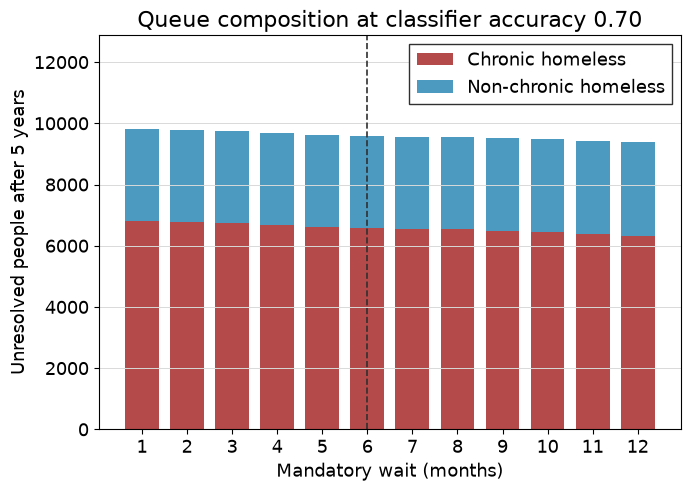

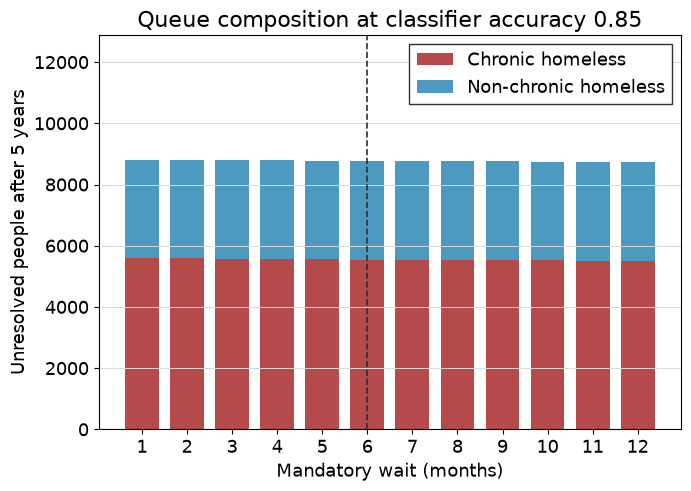

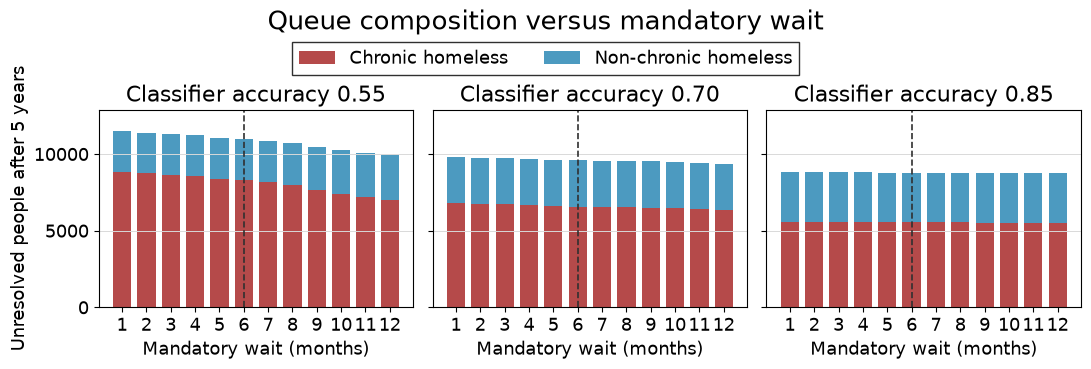

In [147]:
queue_total_max = (wait_summary["end_queue_chronic"] + wait_summary["end_queue_nonchronic"]).max()
for accuracy in PLOT_ACCURACIES:
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)
    data = wait_summary[wait_summary["classifier_accuracy"] == accuracy].sort_values("mandatory_wait_months")
    waits = data["mandatory_wait_months"]
    chronic_queue = data["end_queue_chronic"]
    nonchronic_queue = data["end_queue_nonchronic"]
    ax.bar(waits, chronic_queue, width=0.75, color="#B54A4A", label="Chronic homeless")
    ax.bar(waits, nonchronic_queue, width=0.75, bottom=chronic_queue, color="#4C9AC0", label="Non-chronic homeless")
    ax.axvline(6, color="#303030", linestyle="--", linewidth=1.2)
    ax.set(
        title=f"Queue composition at classifier accuracy {accuracy:.2f}",
        xlabel="Mandatory wait (months)",
        ylabel=f"Unresolved people after {FIGURE_HORIZON_YEARS:g} years",
        xticks=WAIT_MONTH_GRID,
        ylim=(0, queue_total_max * 1.06),
    )
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.7)
    ax.legend(frameon=True, fancybox=False, framealpha=1.0, edgecolor="#303030", loc="upper right")
    accuracy_tag = f"{accuracy:.2f}".replace(".", "_")
    save_figure(fig, f"figure_2_queue_composition_accuracy_{accuracy_tag}.png")
    plt.show()

# Optional combined version, retaining the original Figure 2 title.
fig, axes = plt.subplots(
    1,
    len(PLOT_ACCURACIES),
    figsize=(FIGURE_2_COMBINED_WIDTH, FIGURE_2_COMBINED_HEIGHT),
    sharey=True,
)
for ax, accuracy in zip(axes, PLOT_ACCURACIES):
    data = wait_summary[wait_summary["classifier_accuracy"] == accuracy].sort_values("mandatory_wait_months")
    waits = data["mandatory_wait_months"]
    chronic_queue = data["end_queue_chronic"]
    nonchronic_queue = data["end_queue_nonchronic"]
    ax.bar(waits, chronic_queue, width=0.75, color="#B54A4A", label="Chronic homeless")
    ax.bar(waits, nonchronic_queue, width=0.75, bottom=chronic_queue, color="#4C9AC0", label="Non-chronic homeless")
    ax.axvline(6, color="#303030", linestyle="--", linewidth=1.2)
    ax.set(
        title=f"Classifier accuracy {accuracy:.2f}",
        xlabel="Mandatory wait (months)",
        xticks=WAIT_MONTH_GRID,
        ylim=(0, queue_total_max * 1.06),
    )
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.7)
axes[0].set_ylabel(f"Unresolved people after {FIGURE_HORIZON_YEARS:g} years")
handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle("Queue composition versus mandatory wait", fontsize=1.2 * TITLE_FONT_SIZE, y=0.91)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.85),
    ncol=2,
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor="#303030",
)
save_figure(fig, "figure_2_queue_composition_combined.png", rect=(0, 0, 1, 0.86))
plt.show()

## Figure 3: housing supply versus classifier accuracy

Each isoline joins combinations of monthly housing supply and classifier accuracy that give the same chronic mortality outcome at a six-month wait.

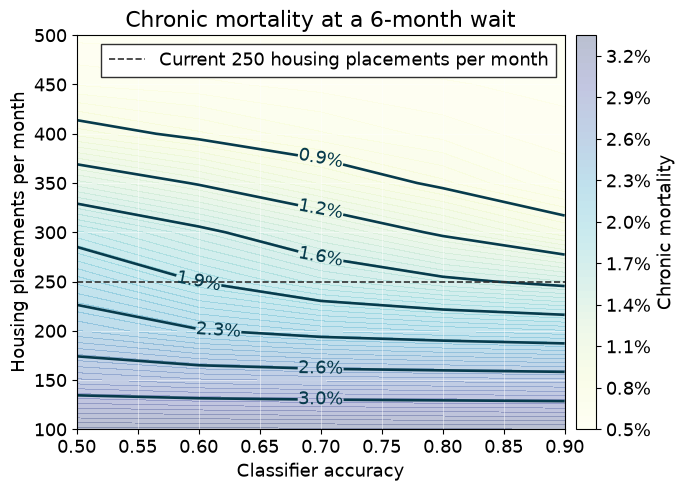

In [132]:
# supply_raw = run_grid(CONTOUR_ACCURACIES, HOUSING_SUPPLY_GRID, [6])
supply_summary = mean_outcomes(supply_raw)
supply_surface = supply_summary.pivot(index="housing_per_month", columns="classifier_accuracy", values="chronic_mortality_probability")
x_accuracy, y_housing = np.meshgrid(supply_surface.columns.to_numpy(), supply_surface.index.to_numpy())

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
supply_values = supply_surface.to_numpy()
supply_levels = np.linspace(supply_values.min(), supply_values.max(), 9)
background = ax.contourf(x_accuracy, y_housing, supply_values, levels=64, cmap="YlGnBu", alpha=0.28)
contours = ax.contour(x_accuracy, y_housing, supply_values, levels=supply_levels, colors="#073B4C", linewidths=1.9)
ax.clabel(contours, inline=True, inline_spacing=3, fontsize=FONT_SIZE, fmt=lambda x: f"{x:.1%}")
colourbar = fig.colorbar(background, ax=ax, pad=0.02, format=PercentFormatter(xmax=1.0, decimals=1))
colourbar.set_label("Chronic mortality")
ax.axhline(250, color="#303030", linestyle="--", linewidth=1.2, label="Current 250 housing placements per month")
ax.set(xlabel="Classifier accuracy", ylabel="Housing placements per month", title="Chronic mortality at a 6-month wait")
ax.grid(color="white", linewidth=0.6, alpha=0.55)
ax.legend(frameon=True, fancybox=False, framealpha=1.0, edgecolor="#303030")
save_figure(fig, "figure_3_supply_accuracy_isolines.png")
plt.show()

## Figure 4: mandatory wait versus classifier accuracy

These isolines show whether a more accurate classifier can support a shorter mandatory wait while retaining the same chronic mortality outcome at 250 placements per month.

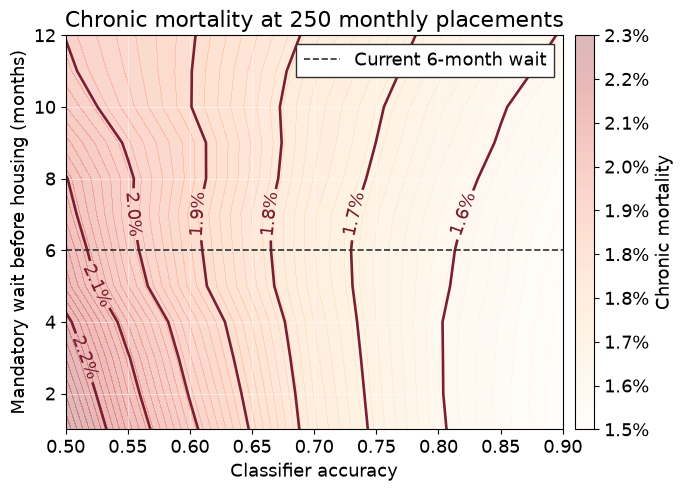

In [134]:
wait_surface = wait_summary.pivot(index="mandatory_wait_months", columns="classifier_accuracy", values="chronic_mortality_probability")
x_accuracy, y_wait = np.meshgrid(wait_surface.columns.to_numpy(), wait_surface.index.to_numpy())

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
wait_values = wait_surface.to_numpy()
wait_levels = np.linspace(wait_values.min(), wait_values.max(), 9)
background = ax.contourf(x_accuracy, y_wait, wait_values, levels=64, cmap="OrRd", alpha=0.28)
contours = ax.contour(x_accuracy, y_wait, wait_values, levels=wait_levels, colors="#7A1F31", linewidths=1.9)
ax.clabel(contours, inline=True, inline_spacing=3, fontsize=FONT_SIZE, fmt=lambda x: f"{x:.1%}")
colourbar = fig.colorbar(background, ax=ax, pad=0.02, format=PercentFormatter(xmax=1.0, decimals=1))
colourbar.set_label("Chronic mortality")
ax.axhline(6, color="#303030", linestyle="--", linewidth=1.2, label="Current 6-month wait")
ax.set(xlabel="Classifier accuracy", ylabel="Mandatory wait before housing (months)", title="Chronic mortality at 250 monthly placements")
ax.grid(color="white", linewidth=0.6, alpha=0.55)
ax.legend(frameon=True, fancybox=False, framealpha=1.0, edgecolor="#303030")
save_figure(fig, "figure_4_wait_accuracy_isolines.png")
plt.show()